# Results — config comparison

Generated from `results.csv` — one row per execution across ALL configs (**416 execution(s)**). Each config is one experiment.

Four diagrams, one per metric that counts. Each bar is a config, averaged across all of its executions (every task, interface, version, skills, repeat); the dashed line is the mean across all configs.

- **pass rate** = `asserts_passed / total_asserts` — ↑ higher is better
- **local_time_s** — ↓ lower is better
- **cost_usd** — ↓ lower is better
- **llm_calls** — ↓ lower is better


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv("results.csv")
num = raw.copy()
for c in ['asserts_passed', 'total_asserts', 'local_time_s', 'cost_usd', 'llm_calls']:
    if c in num.columns:
        num[c] = pd.to_numeric(num[c], errors='coerce')
# Pass rate per execution; total_asserts == 0 -> undefined (NaN).
num['pass_rate'] = num['asserts_passed'] / num['total_asserts'].replace(0, pd.NA)
configs = sorted(num['config'].dropna().astype(str).unique())
DIR_MARK = {'max': '\u2191 higher is better', 'min': '\u2193 lower is better'}
print(f'{len(num)} executions across {len(configs)} configs')


416 executions across 4 configs


## pass rate (asserts_passed / total_asserts)

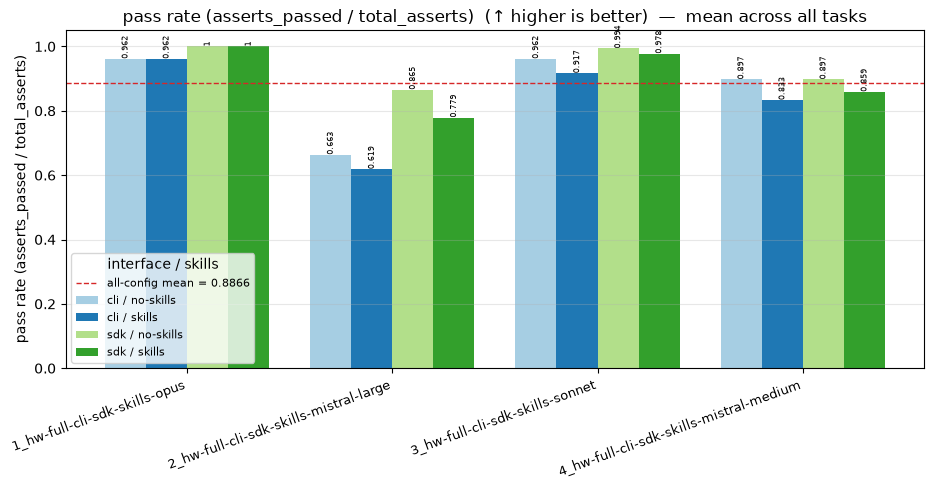

In [2]:
col, label, direction = "pass_rate", "pass rate (asserts_passed / total_asserts)", "max"
# Four sub-bars per config: interface (cli/sdk) x skills (with/without).
SUB = [('cli', 'none', 'cli / no-skills'), ('cli', 'official', 'cli / skills'),
       ('sdk', 'none', 'sdk / no-skills'), ('sdk', 'official', 'sdk / skills')]
piv = num.groupby(['config', 'interface', 'skills'])[col].mean()
x = range(len(configs))
nsub = len(SUB)
width = 0.8 / nsub
fig, ax = plt.subplots(figsize=(max(9, 2.4 * len(configs)), 5))
colors = plt.cm.Paired.colors
for j, (iface, sk, lab) in enumerate(SUB):
    vals = [piv.get((cfg, iface, sk), float('nan')) for cfg in configs]
    offs = [i + (j - (nsub - 1) / 2) * width for i in x]
    ax.bar(offs, vals, width=width, label=lab, color=colors[j])
    for o, v in zip(offs, vals):
        if pd.notna(v):
            ax.text(o, v, f'{v:.3g}', ha='center', va='bottom', fontsize=6, rotation=90)
overall = num[col].mean()
if pd.notna(overall):
    ax.axhline(overall, color='tab:red', linestyle='--', linewidth=1,
               label=f'all-config mean = {overall:.4g}')
ax.set_xticks(list(x))
ax.set_xticklabels(configs, rotation=20, ha='right', fontsize=9)
ax.set_ylabel(label)
ax.set_title(f'{label}  ({DIR_MARK[direction]})  \u2014  mean across all tasks')
ax.legend(title='interface / skills', fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## local_time_s

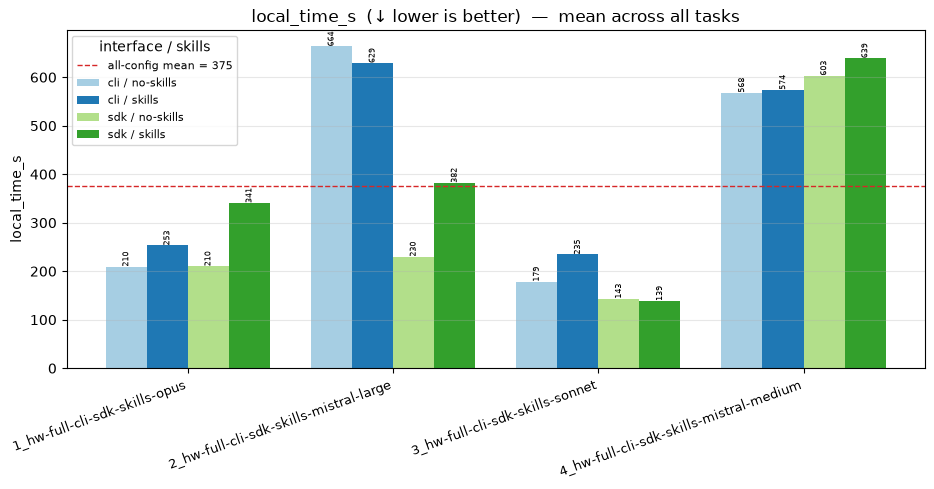

In [3]:
col, label, direction = "local_time_s", "local_time_s", "min"
# Four sub-bars per config: interface (cli/sdk) x skills (with/without).
SUB = [('cli', 'none', 'cli / no-skills'), ('cli', 'official', 'cli / skills'),
       ('sdk', 'none', 'sdk / no-skills'), ('sdk', 'official', 'sdk / skills')]
piv = num.groupby(['config', 'interface', 'skills'])[col].mean()
x = range(len(configs))
nsub = len(SUB)
width = 0.8 / nsub
fig, ax = plt.subplots(figsize=(max(9, 2.4 * len(configs)), 5))
colors = plt.cm.Paired.colors
for j, (iface, sk, lab) in enumerate(SUB):
    vals = [piv.get((cfg, iface, sk), float('nan')) for cfg in configs]
    offs = [i + (j - (nsub - 1) / 2) * width for i in x]
    ax.bar(offs, vals, width=width, label=lab, color=colors[j])
    for o, v in zip(offs, vals):
        if pd.notna(v):
            ax.text(o, v, f'{v:.3g}', ha='center', va='bottom', fontsize=6, rotation=90)
overall = num[col].mean()
if pd.notna(overall):
    ax.axhline(overall, color='tab:red', linestyle='--', linewidth=1,
               label=f'all-config mean = {overall:.4g}')
ax.set_xticks(list(x))
ax.set_xticklabels(configs, rotation=20, ha='right', fontsize=9)
ax.set_ylabel(label)
ax.set_title(f'{label}  ({DIR_MARK[direction]})  \u2014  mean across all tasks')
ax.legend(title='interface / skills', fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## cost_usd

In [4]:
col, label, direction = "cost_usd", "cost_usd", "min"
# Four sub-bars per config: interface (cli/sdk) x skills (with/without).
SUB = [('cli', 'none', 'cli / no-skills'), ('cli', 'official', 'cli / skills'),
       ('sdk', 'none', 'sdk / no-skills'), ('sdk', 'official', 'sdk / skills')]
piv = num.groupby(['config', 'interface', 'skills'])[col].mean()
x = range(len(configs))
nsub = len(SUB)
width = 0.8 / nsub
fig, ax = plt.subplots(figsize=(max(9, 2.4 * len(configs)), 5))
colors = plt.cm.Paired.colors
for j, (iface, sk, lab) in enumerate(SUB):
    vals = [piv.get((cfg, iface, sk), float('nan')) for cfg in configs]
    offs = [i + (j - (nsub - 1) / 2) * width for i in x]
    ax.bar(offs, vals, width=width, label=lab, color=colors[j])
    for o, v in zip(offs, vals):
        if pd.notna(v):
            ax.text(o, v, f'{v:.3g}', ha='center', va='bottom', fontsize=6, rotation=90)
overall = num[col].mean()
if pd.notna(overall):
    ax.axhline(overall, color='tab:red', linestyle='--', linewidth=1,
               label=f'all-config mean = {overall:.4g}')
ax.set_xticks(list(x))
ax.set_xticklabels(configs, rotation=20, ha='right', fontsize=9)
ax.set_ylabel(label)
ax.set_title(f'{label}  ({DIR_MARK[direction]})  \u2014  mean across all tasks')
ax.legend(title='interface / skills', fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## llm_calls

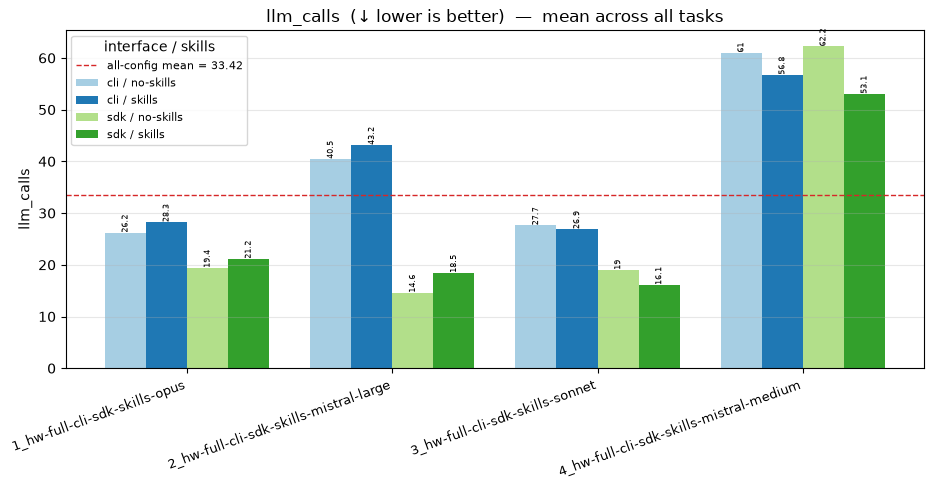

In [5]:
col, label, direction = "llm_calls", "llm_calls", "min"
# Four sub-bars per config: interface (cli/sdk) x skills (with/without).
SUB = [('cli', 'none', 'cli / no-skills'), ('cli', 'official', 'cli / skills'),
       ('sdk', 'none', 'sdk / no-skills'), ('sdk', 'official', 'sdk / skills')]
piv = num.groupby(['config', 'interface', 'skills'])[col].mean()
x = range(len(configs))
nsub = len(SUB)
width = 0.8 / nsub
fig, ax = plt.subplots(figsize=(max(9, 2.4 * len(configs)), 5))
colors = plt.cm.Paired.colors
for j, (iface, sk, lab) in enumerate(SUB):
    vals = [piv.get((cfg, iface, sk), float('nan')) for cfg in configs]
    offs = [i + (j - (nsub - 1) / 2) * width for i in x]
    ax.bar(offs, vals, width=width, label=lab, color=colors[j])
    for o, v in zip(offs, vals):
        if pd.notna(v):
            ax.text(o, v, f'{v:.3g}', ha='center', va='bottom', fontsize=6, rotation=90)
overall = num[col].mean()
if pd.notna(overall):
    ax.axhline(overall, color='tab:red', linestyle='--', linewidth=1,
               label=f'all-config mean = {overall:.4g}')
ax.set_xticks(list(x))
ax.set_xticklabels(configs, rotation=20, ha='right', fontsize=9)
ax.set_ylabel(label)
ax.set_title(f'{label}  ({DIR_MARK[direction]})  \u2014  mean across all tasks')
ax.legend(title='interface / skills', fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
